In [1]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [3]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer
from sensor_modules import SensorModule
from reconstruction_modules import WienerDeconv, UNetDeconv

2026-03-10 14:30:08.047271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773178208.068471 3344808 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773178208.074369 3344808 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    sensor_module: eqx.Module
    reconstruction_module: eqx.Module

    def __init__(self, 
                 psf_module,
                 sensor_module,
                 reconstruction_module):
        
        self.psf_module = psf_module
        self.sensor_module = sensor_module
        self.reconstruction_module = reconstruction_module
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None, ensure_positive=True) -> tuple:
        # x: (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key # TODO: ask claude, is this bad seeding?
        psf, y = self.psf_module(x)  # psf:(K, L), y:(B, H, W)
        noisy_y = self.sensor_module(y, key=key, ensure_positive=ensure_positive)
        x_hat = self.reconstruction_module(noisy_y, psf) # (B, H, W)
        
        return x_hat, noisy_y, psf

In [5]:
# general
lr_psf = 1e-2
lr_recon = 1e-4
seed_value = 42 #TODO: FIX SEEDING
key = jax.random.PRNGKey(seed_value)

# loading images
tile_rows=3
tile_cols=3
batch_size=32  
dataset_name = 'mnist'
photon_count = 160
subset_fraction = 1

# psf stuff constants
psf_size = (32, 32)
object_size = 32
num_gaussian = 10

# sensor stuff
noise_enabled = True
sensor_array_enabled = True
gaussian_sigma = 0.5

sensor_array_params = { #TODO: figure out if you can save this in wandb?
    "H": 96,
    "W": 96, 
    "rows": 3,
    "cols": 3,
    "sensor_h": 10,
    "sensor_w": 15,
    "spacing_y": 20,
    "spacing_x": 18
}

# recon stuff
recon_name = 'unet'
log_K = jnp.array(-4.0) #initial starting K value for wiener deconv

# train stuff
num_steps = 1000
log_every_print = 20
visualize_every = 50

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging_playground'
run_name = f'{dataset_name}_recon_{recon_name}_gaussian_sigma_{gaussian_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussian}'
log_every = 10

In [6]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
        'num_steps': num_steps
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer_module': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
        'gaussian_sigma': gaussian_sigma
    },

    'sensor_module': {
        'noise_enabled': noise_enabled,
        'sensor_array_enabled': sensor_array_enabled, 
        'gaussian_sigma': gaussian_sigma,
        'sensor_array_params': sensor_array_params
    },

    'reconstruction_module': {
        'initial log_K': log_K,
        'learning_rate_psf': lr_psf,
        'learning_rate_recon': lr_recon
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [7]:
# load images!
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)

if dataset_name == 'cifar10':
    x_train, x_test = data_generator.load_cifar10_data()
elif dataset_name == 'mnist':
    x_train, x_test = data_generator.load_mnist_data()

train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)
x_train[0].shape[0] * tile_rows

2026-03-10 14:30:18.559718: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1773178218.560044 3344808 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5744 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6


96

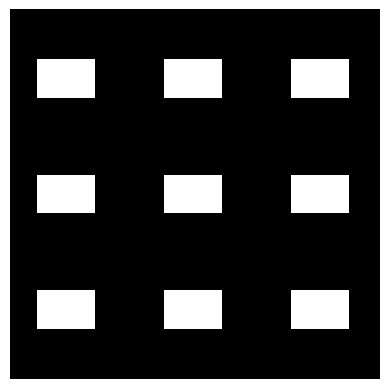

In [ ]:
# the model
key_1, subkey_1 = jax.random.split(key) # TODO: replace this with self.next_rng_key()??
key_2, subkey_2 = jax.random.split(key_1)
key_3, subkey_3 = jax.random.split(key_2)

psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
sensor_module = SensorModule(photon_count=photon_count, 
                             noise_enabled=noise_enabled,
                             sensor_array_enabled=sensor_array_enabled, 
                             gaussian_sigma=gaussian_sigma, 
                             sensor_array_params= sensor_array_params)

if recon_name == 'wiener':
    reconstruction_module = WienerDeconv(log_K)
if recon_name == 'unet':
    reconstruction_module = UNetDeconv(key = subkey_2) # TODO: fix the size dimension (second entry)

model = E2E(psf_module=psf_module, sensor_module=sensor_module, reconstruction_module=reconstruction_module)
plt.imshow(model.sensor_module.create_sensor_array(), cmap='gray')
plt.axis('off')
plt.show()

In [11]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr_psf=lr_psf,
    lr_recon=lr_recon,
    use_wandb=use_wandb, 
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

  0%|          | 0/500 [00:00<?, ?it/s]E0309 22:50:20.677826 3137681 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


step 0/500  loss=0.258581


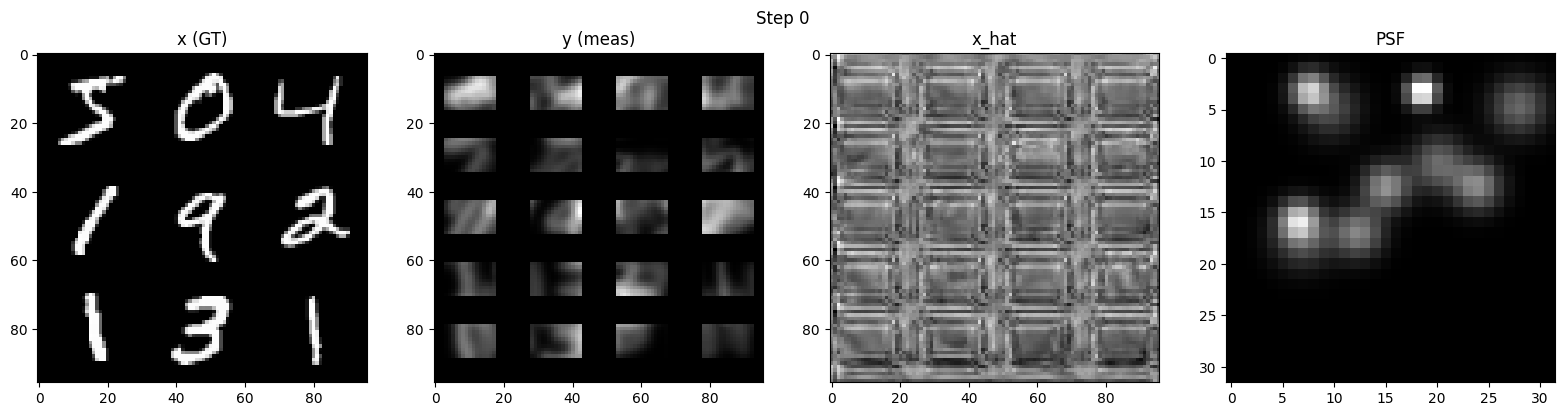

  2%|▏         | 11/500 [01:52<26:16,  3.22s/it]  

step 10/500  loss=0.119553


  4%|▍         | 20/500 [02:11<17:42,  2.21s/it]

step 20/500  loss=0.103986


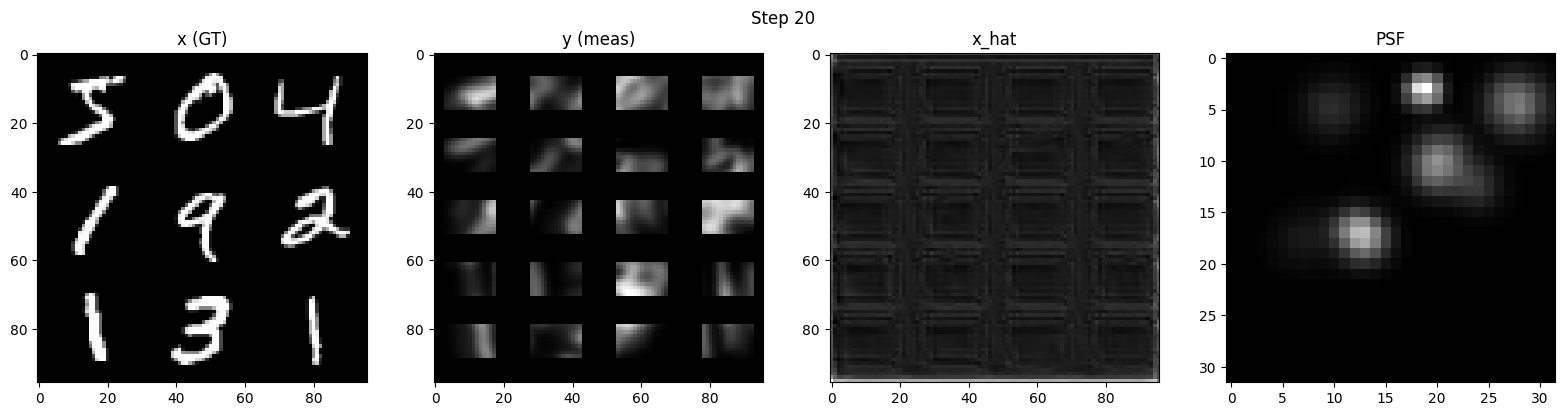

  6%|▌         | 31/500 [02:36<17:10,  2.20s/it]

step 30/500  loss=0.096016


  8%|▊         | 40/500 [02:57<16:36,  2.17s/it]

step 40/500  loss=0.089118


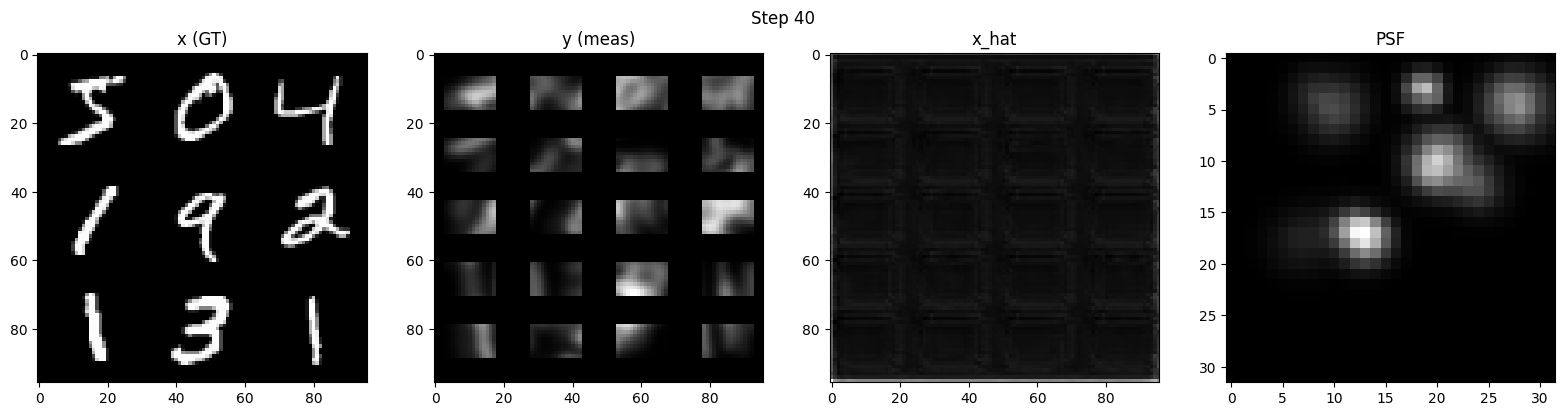

 10%|█         | 51/500 [03:22<16:23,  2.19s/it]

step 50/500  loss=0.083147


 12%|█▏        | 60/500 [03:41<15:23,  2.10s/it]

step 60/500  loss=0.082679


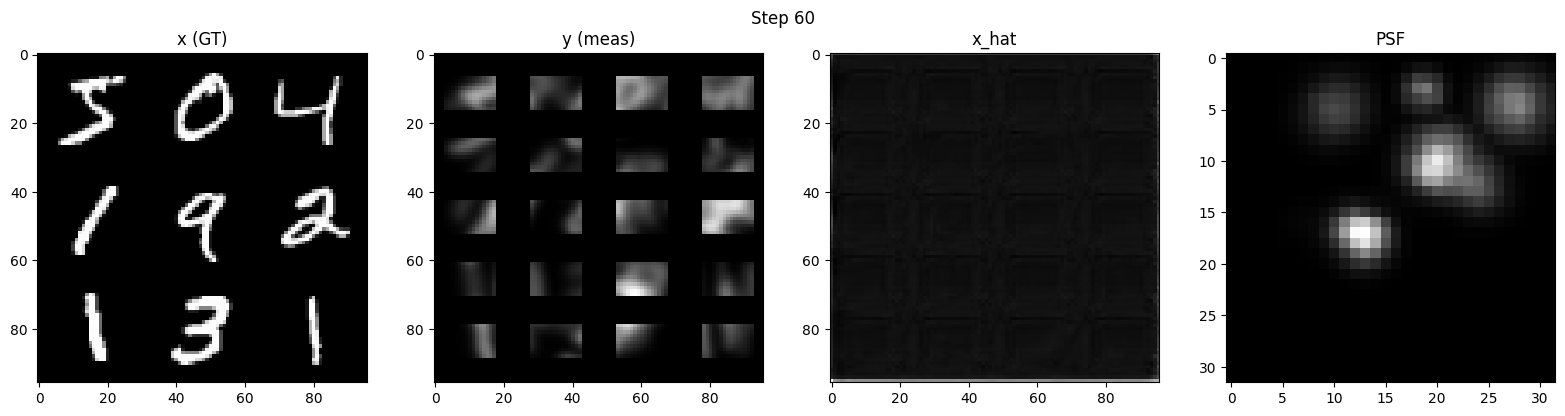

 14%|█▍        | 71/500 [04:06<14:54,  2.08s/it]

step 70/500  loss=0.081981


 16%|█▌        | 80/500 [04:25<15:24,  2.20s/it]

step 80/500  loss=0.085861


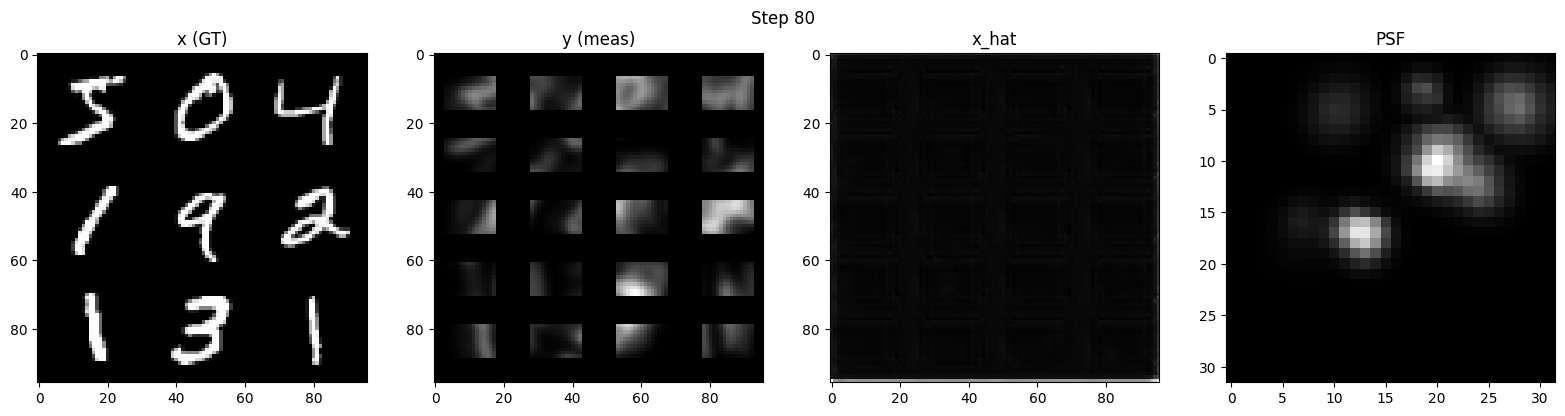

 18%|█▊        | 91/500 [04:51<14:49,  2.17s/it]

step 90/500  loss=0.077851


 20%|██        | 100/500 [05:11<14:39,  2.20s/it]

step 100/500  loss=0.080751


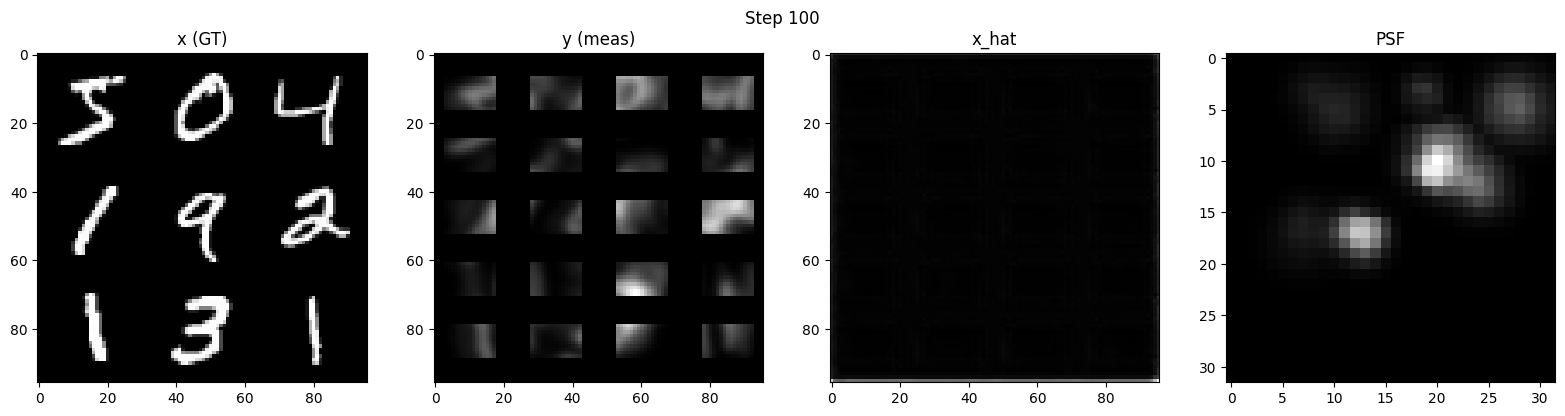

 22%|██▏       | 111/500 [05:36<13:34,  2.09s/it]

step 110/500  loss=0.074156


 24%|██▍       | 120/500 [05:55<13:34,  2.14s/it]

step 120/500  loss=0.078938


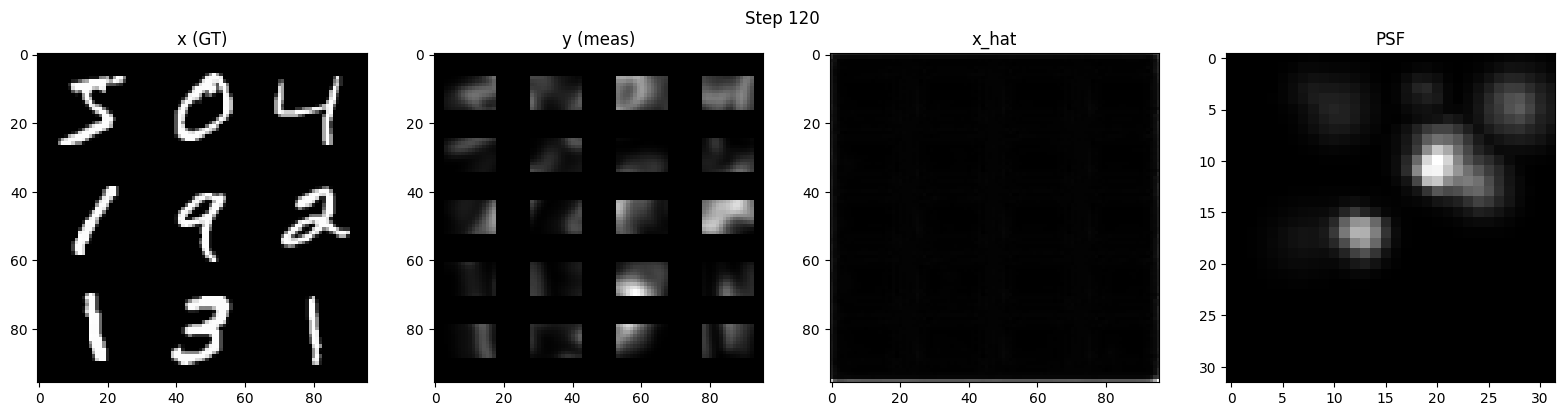

 26%|██▌       | 131/500 [06:20<13:32,  2.20s/it]

step 130/500  loss=0.072231


 28%|██▊       | 140/500 [06:40<13:16,  2.21s/it]

step 140/500  loss=0.082042


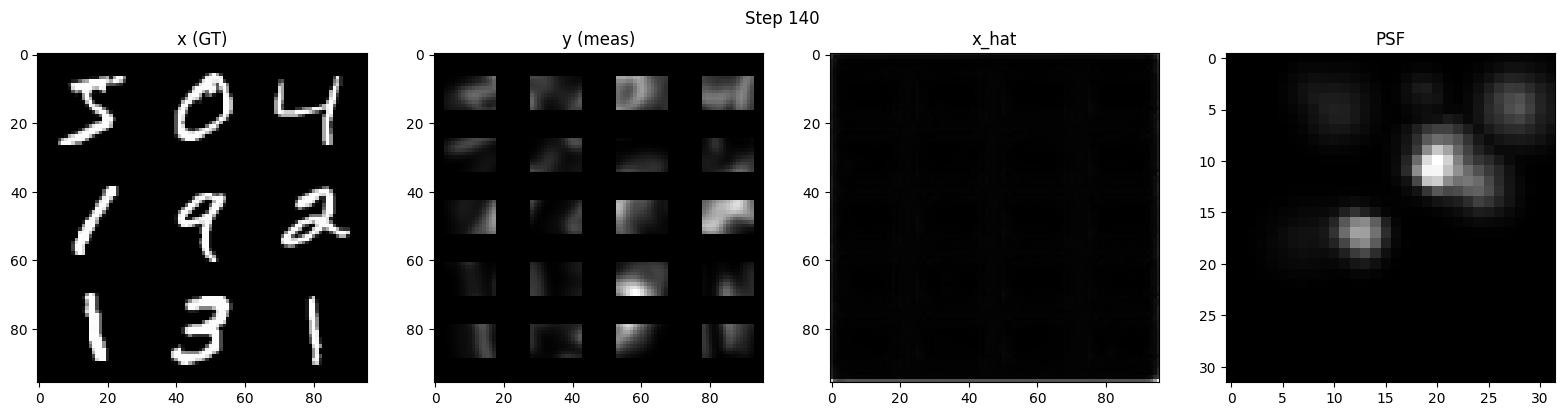

 30%|███       | 151/500 [07:05<13:08,  2.26s/it]

step 150/500  loss=0.078210


 32%|███▏      | 160/500 [07:25<12:46,  2.26s/it]

step 160/500  loss=0.072366


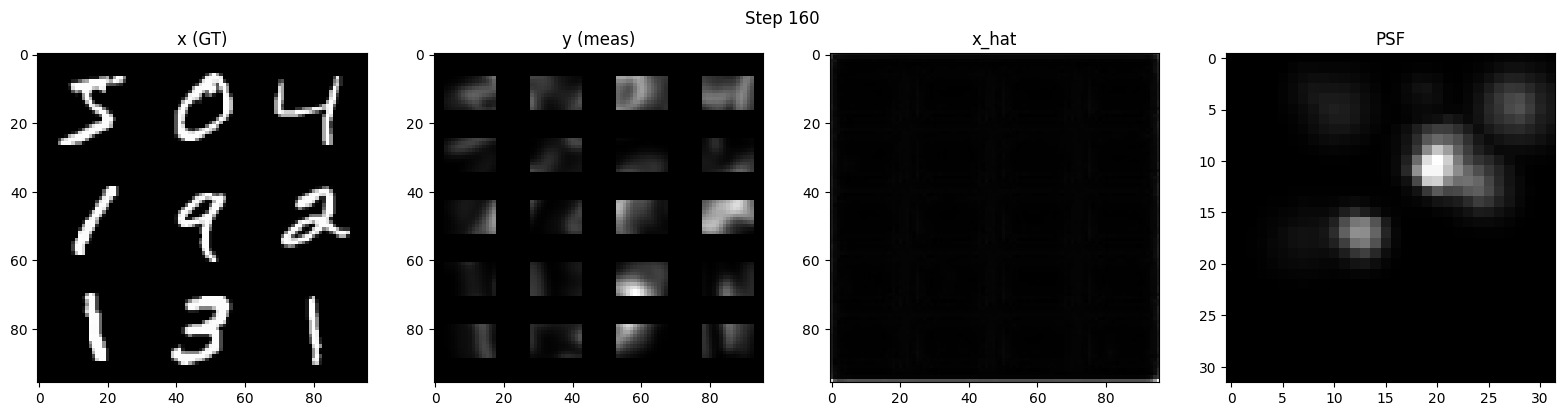

 34%|███▍      | 171/500 [07:50<12:22,  2.26s/it]

step 170/500  loss=0.074898


 36%|███▌      | 180/500 [08:10<12:08,  2.28s/it]

step 180/500  loss=0.071032


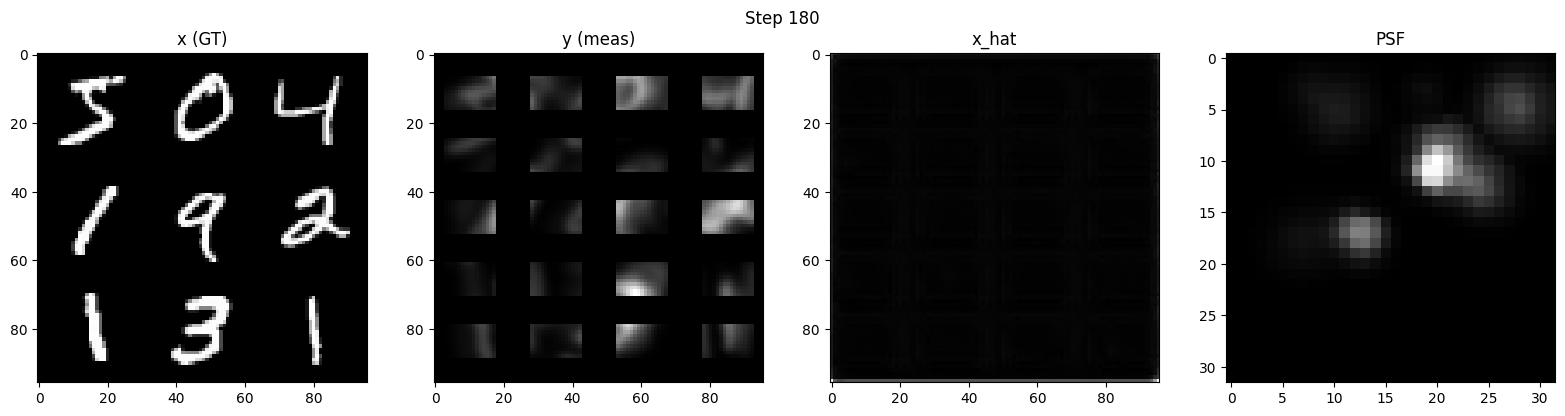

 38%|███▊      | 191/500 [08:35<11:23,  2.21s/it]

step 190/500  loss=0.077570


 40%|████      | 200/500 [08:55<10:58,  2.19s/it]

step 200/500  loss=0.069246


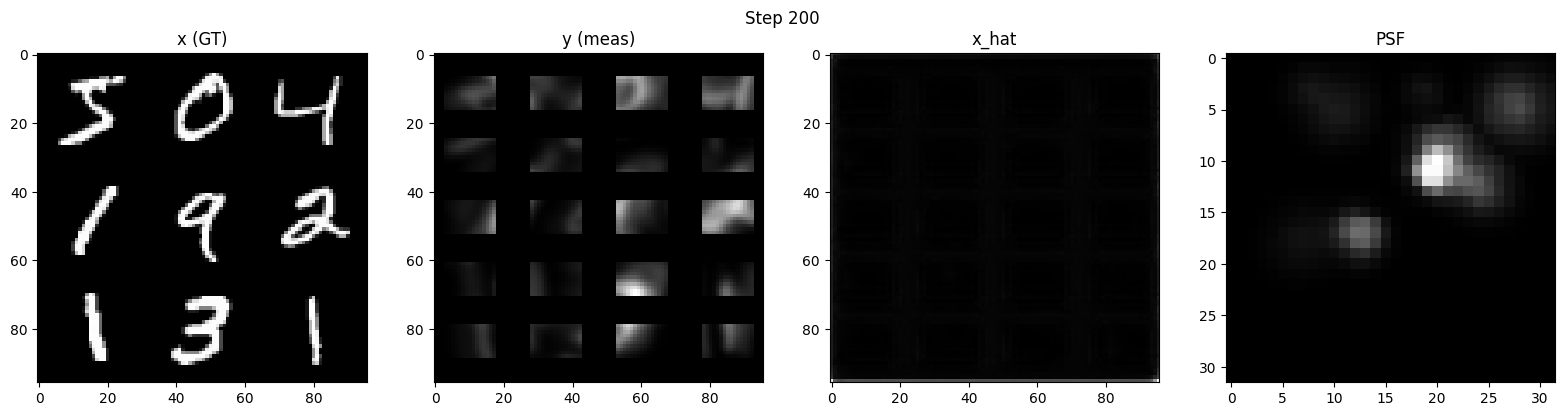

 42%|████▏     | 211/500 [10:16<50:15, 10.43s/it]  

step 210/500  loss=0.073681


 44%|████▍     | 220/500 [10:35<11:40,  2.50s/it]

step 220/500  loss=0.071884


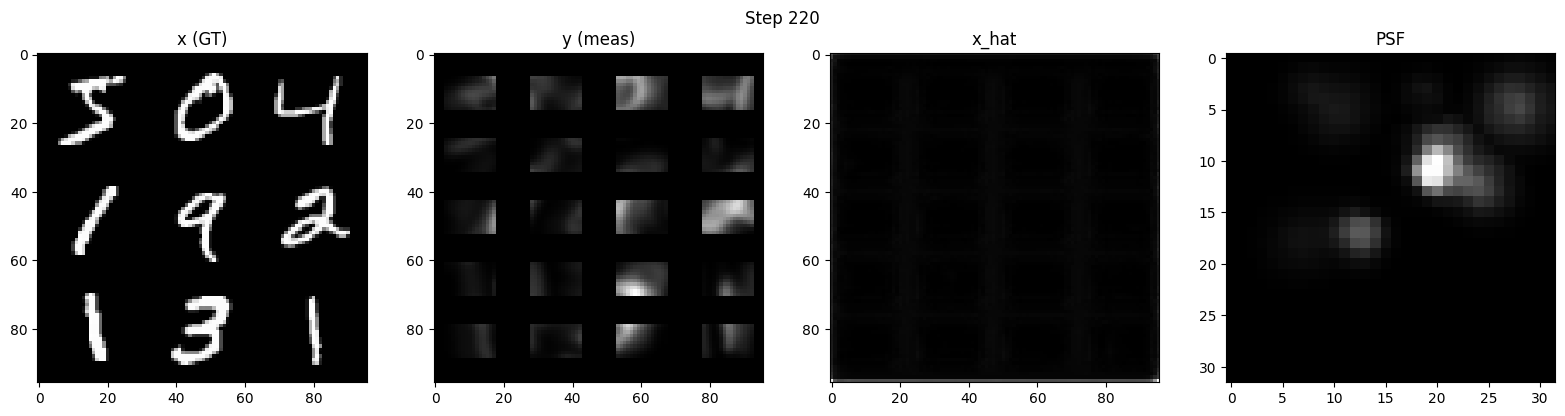

 46%|████▌     | 231/500 [11:00<09:45,  2.18s/it]

step 230/500  loss=0.087759


 48%|████▊     | 240/500 [11:21<10:02,  2.32s/it]

step 240/500  loss=0.073077


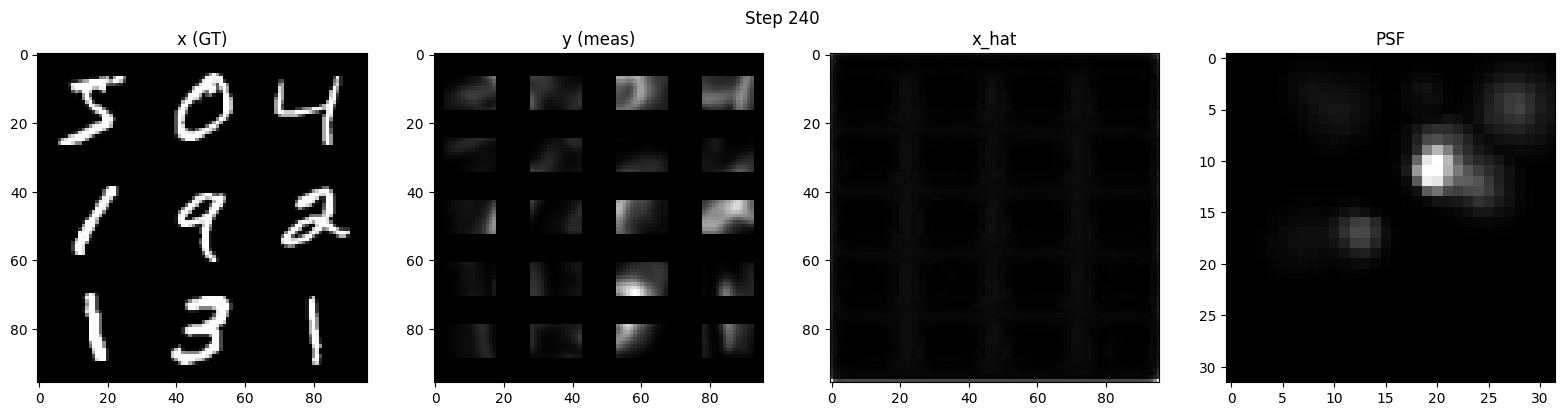

 50%|█████     | 251/500 [11:46<09:41,  2.33s/it]

step 250/500  loss=0.078190


 52%|█████▏    | 260/500 [12:06<08:40,  2.17s/it]

step 260/500  loss=0.076282


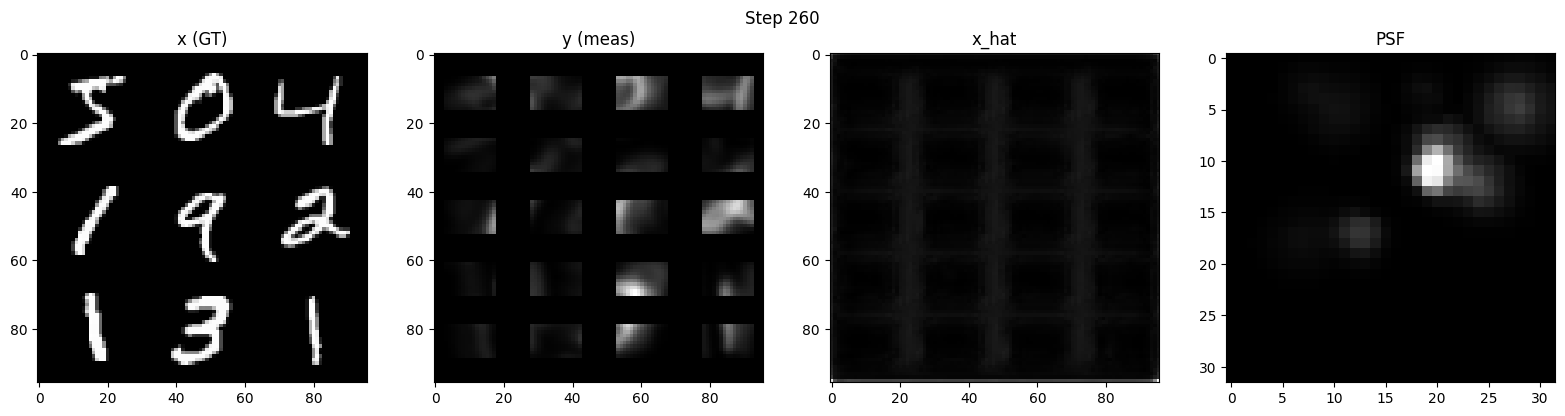

 54%|█████▍    | 271/500 [12:31<08:13,  2.15s/it]

step 270/500  loss=0.069030


 56%|█████▌    | 280/500 [12:51<08:19,  2.27s/it]

step 280/500  loss=0.079146


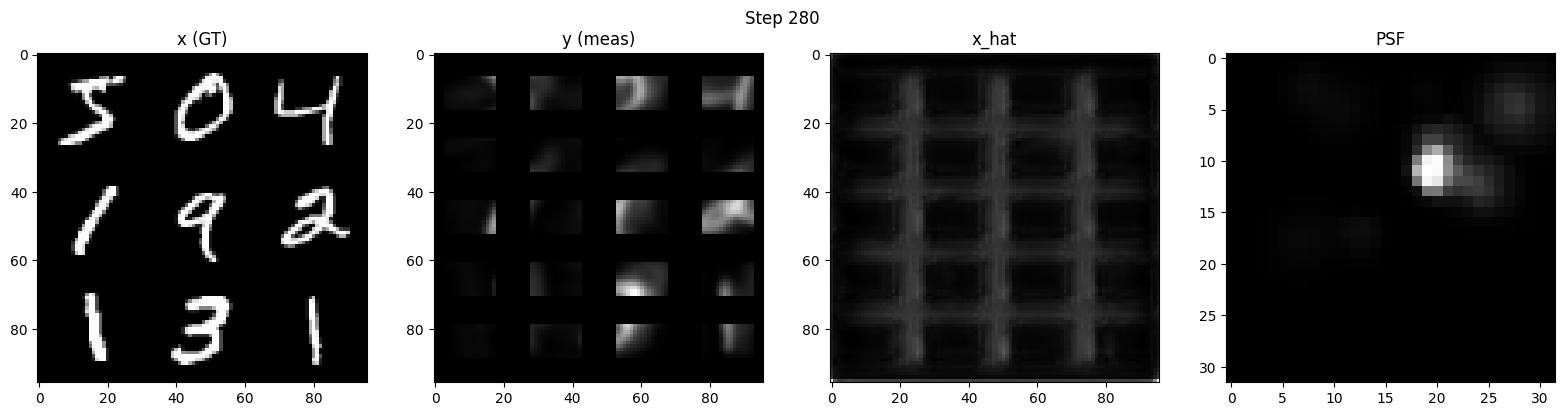

 58%|█████▊    | 291/500 [13:16<07:30,  2.16s/it]

step 290/500  loss=0.075812


 60%|██████    | 300/500 [13:35<07:13,  2.17s/it]

step 300/500  loss=0.069506


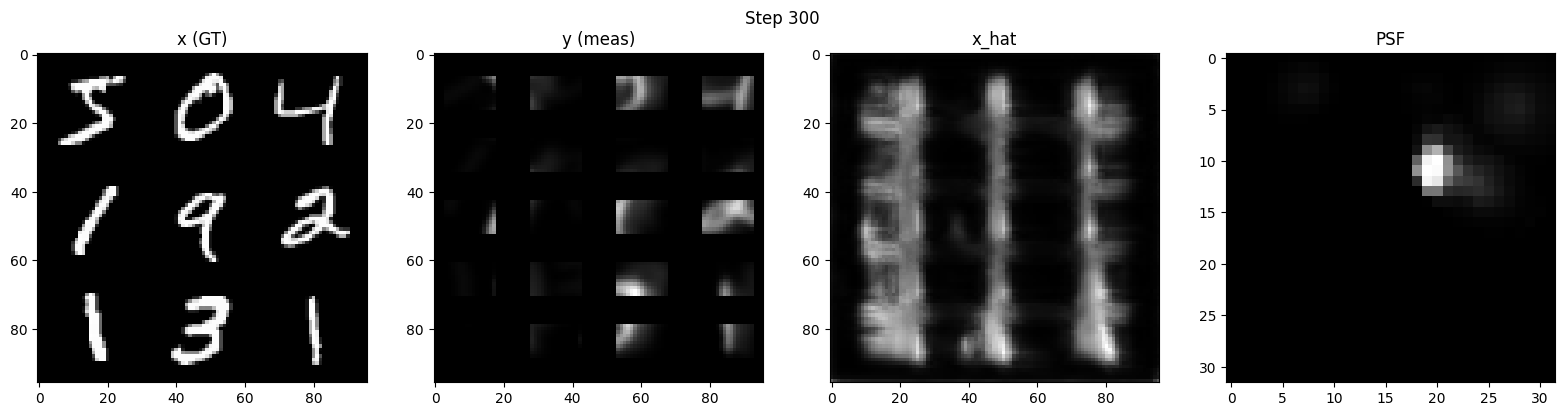

 62%|██████▏   | 311/500 [14:01<06:54,  2.20s/it]

step 310/500  loss=0.077217


 64%|██████▍   | 320/500 [14:21<06:36,  2.20s/it]

step 320/500  loss=0.077286


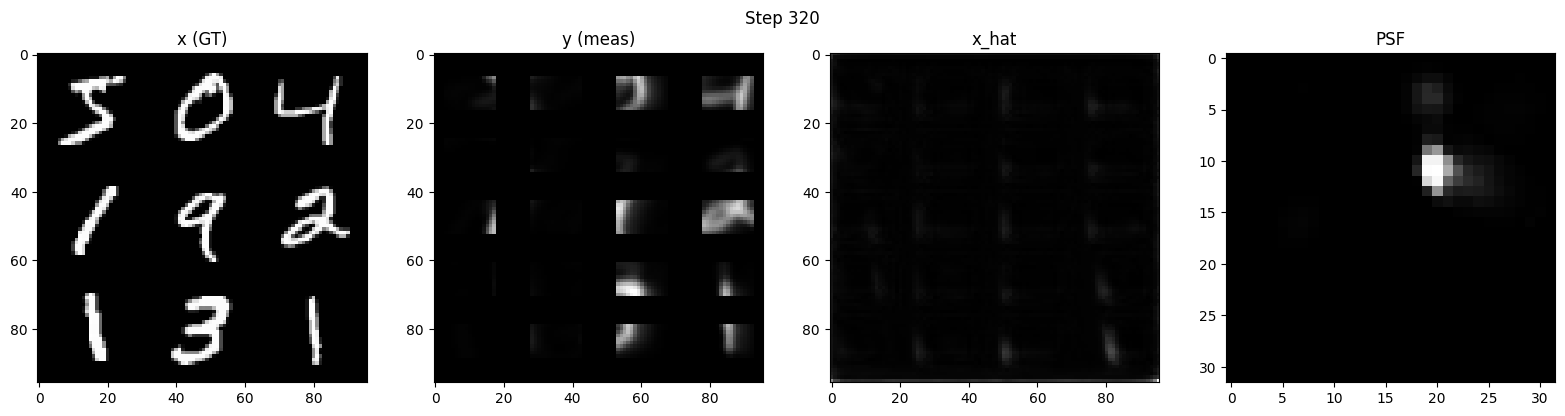

 66%|██████▌   | 331/500 [14:46<06:02,  2.14s/it]

step 330/500  loss=0.076268


 68%|██████▊   | 340/500 [15:06<05:58,  2.24s/it]

step 340/500  loss=0.069382


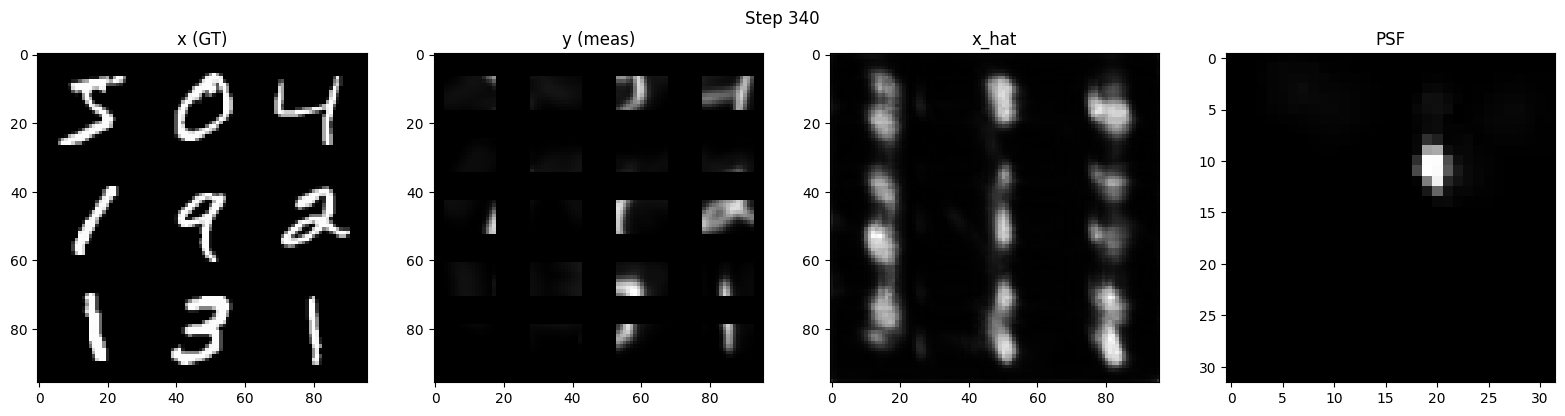

 70%|███████   | 351/500 [15:31<05:35,  2.25s/it]

step 350/500  loss=0.065387


 72%|███████▏  | 360/500 [15:51<05:02,  2.16s/it]

step 360/500  loss=0.059214


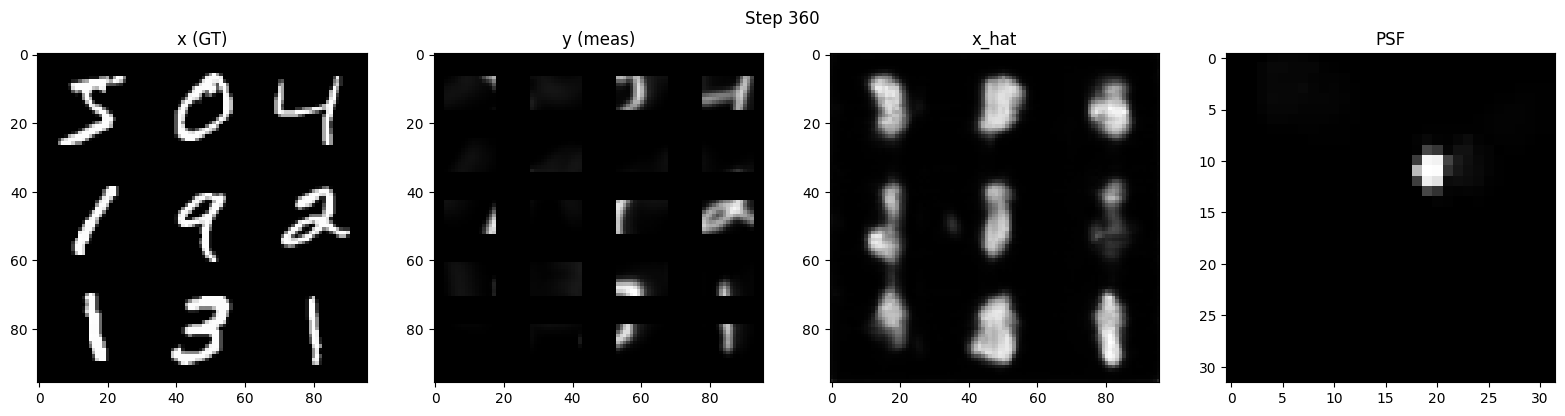

 74%|███████▍  | 371/500 [16:16<04:25,  2.06s/it]

step 370/500  loss=0.056379


 76%|███████▌  | 380/500 [16:36<04:21,  2.18s/it]

step 380/500  loss=0.052973


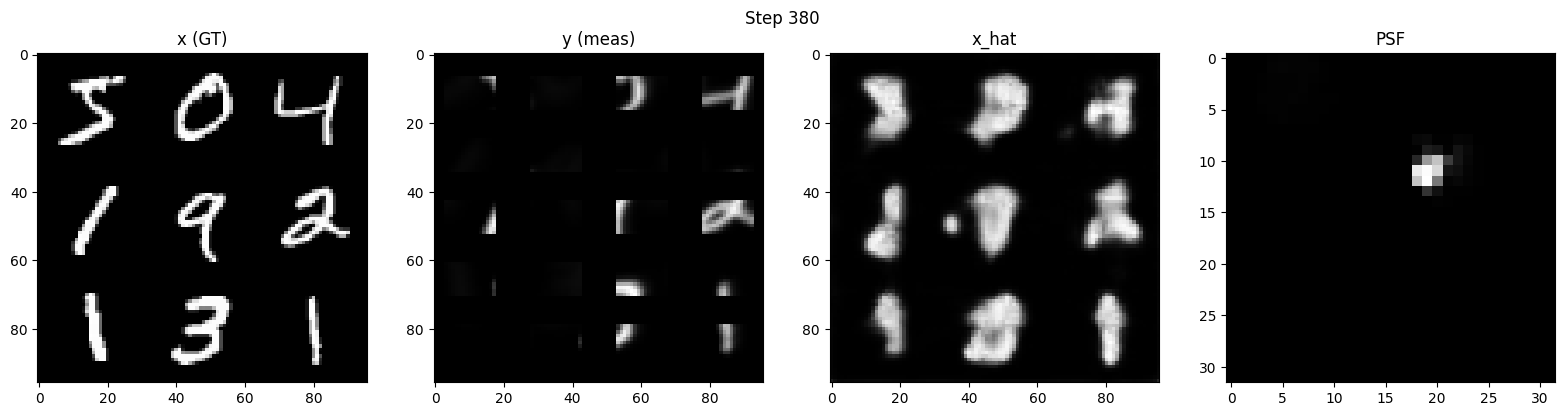

 78%|███████▊  | 391/500 [17:01<04:02,  2.22s/it]

step 390/500  loss=0.045463


 80%|████████  | 400/500 [17:21<03:38,  2.18s/it]

step 400/500  loss=0.044833


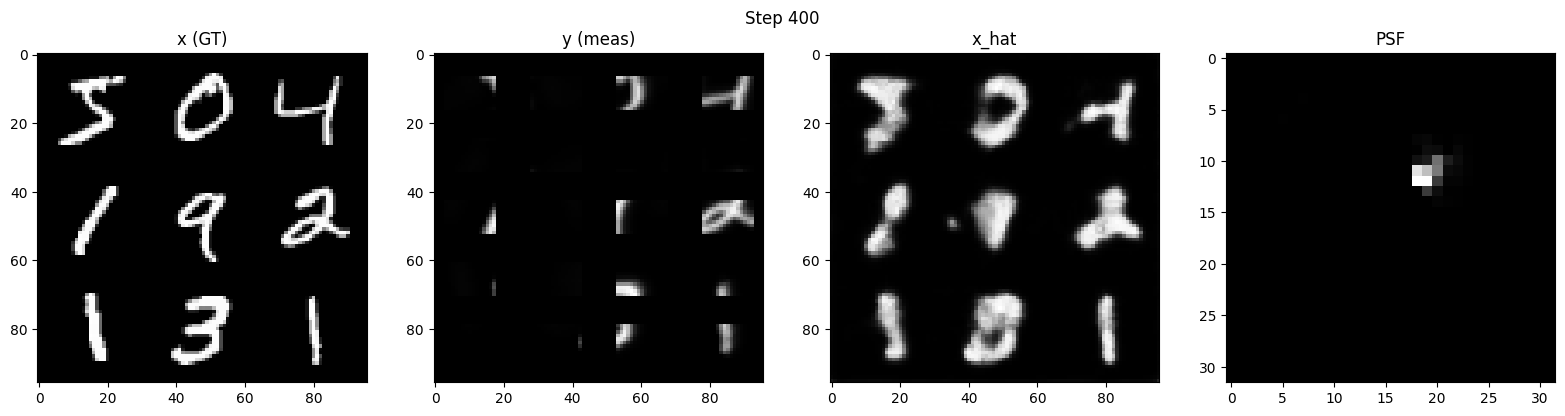

 82%|████████▏ | 411/500 [17:46<03:25,  2.31s/it]

step 410/500  loss=0.040256


 84%|████████▍ | 420/500 [18:05<02:49,  2.12s/it]

step 420/500  loss=0.041957


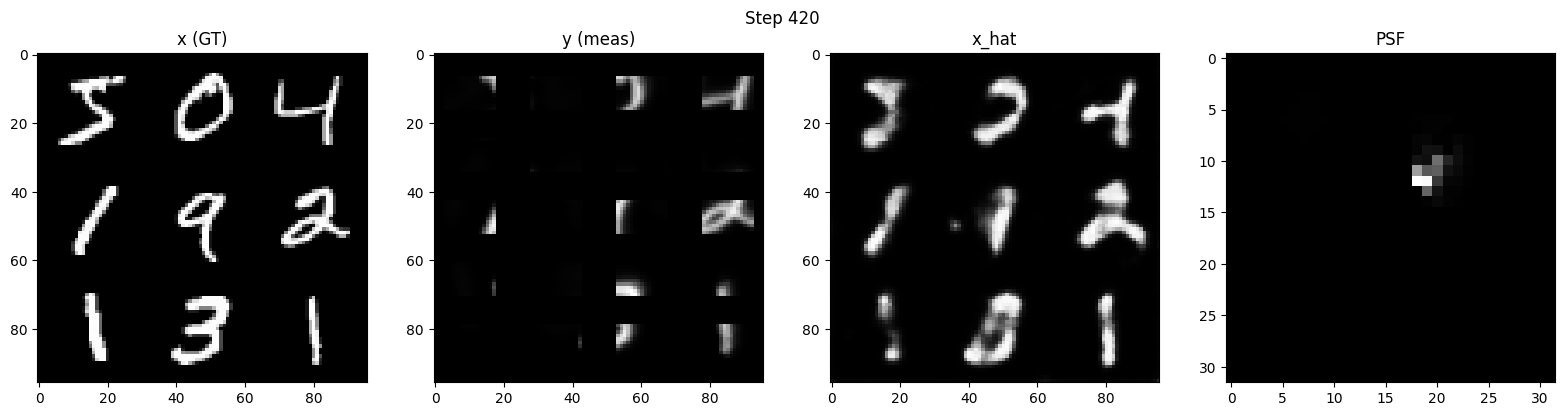

 86%|████████▌ | 431/500 [18:30<02:22,  2.07s/it]

step 430/500  loss=0.038924


 88%|████████▊ | 440/500 [18:50<02:11,  2.18s/it]

step 440/500  loss=0.034761


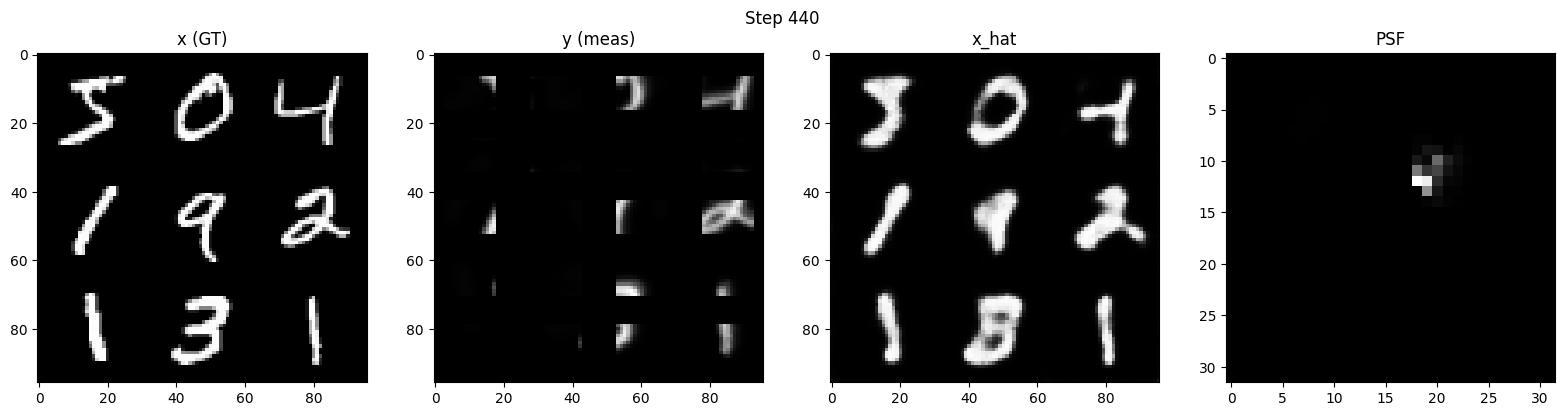

 90%|█████████ | 451/500 [19:16<01:49,  2.23s/it]

step 450/500  loss=0.034417


 92%|█████████▏| 460/500 [19:35<01:26,  2.17s/it]

step 460/500  loss=0.033240


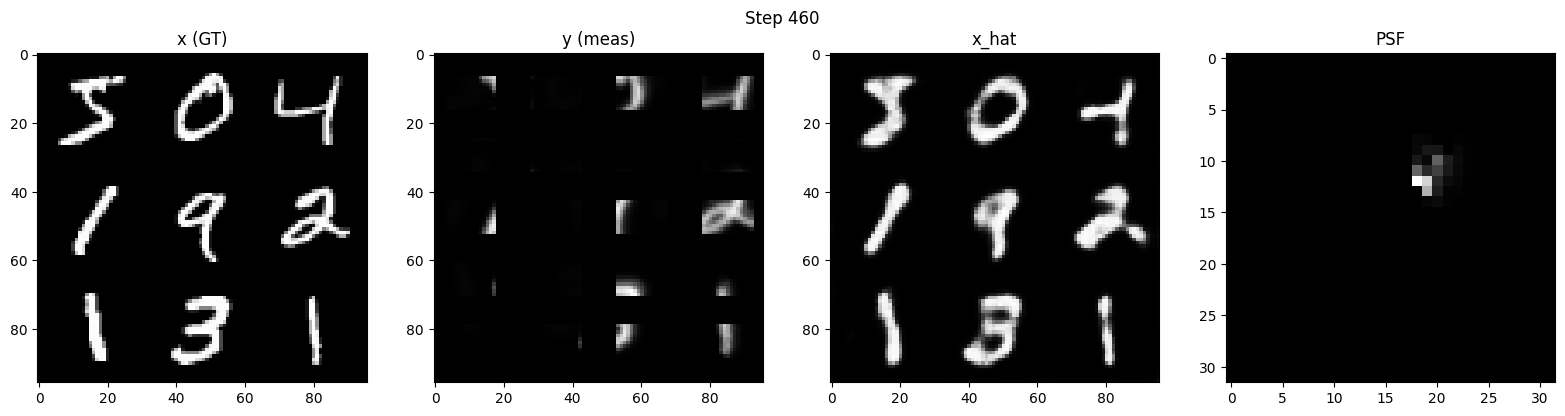

 94%|█████████▍| 471/500 [20:00<01:05,  2.25s/it]

step 470/500  loss=0.030210


 96%|█████████▌| 480/500 [20:20<00:42,  2.15s/it]

step 480/500  loss=0.028181


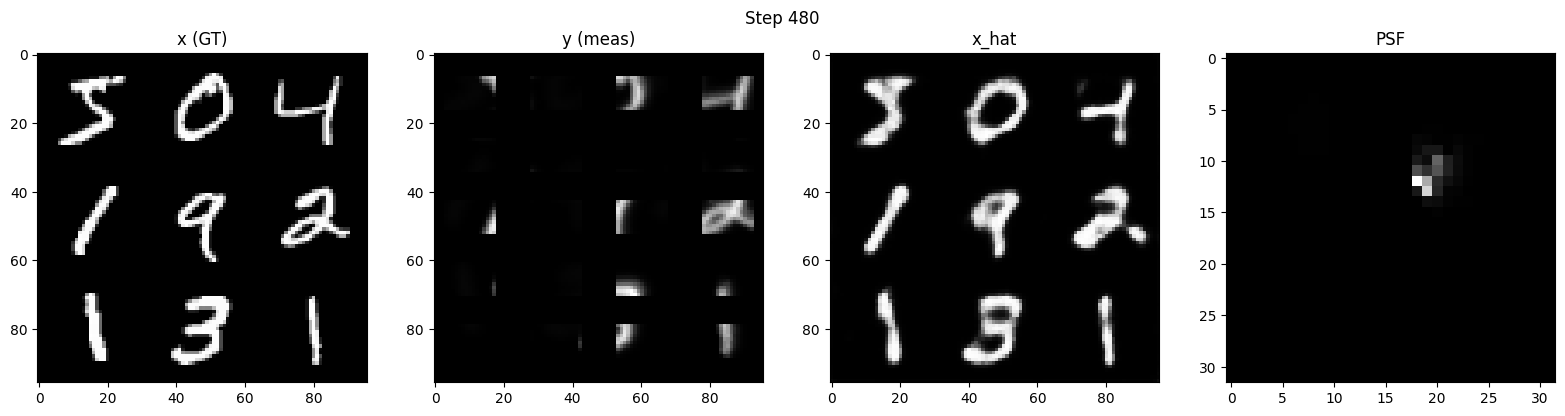

 98%|█████████▊| 491/500 [20:44<00:18,  2.10s/it]

step 490/500  loss=0.027946


100%|█████████▉| 499/500 [21:02<00:02,  2.26s/it]

step 499/500  loss=0.026993


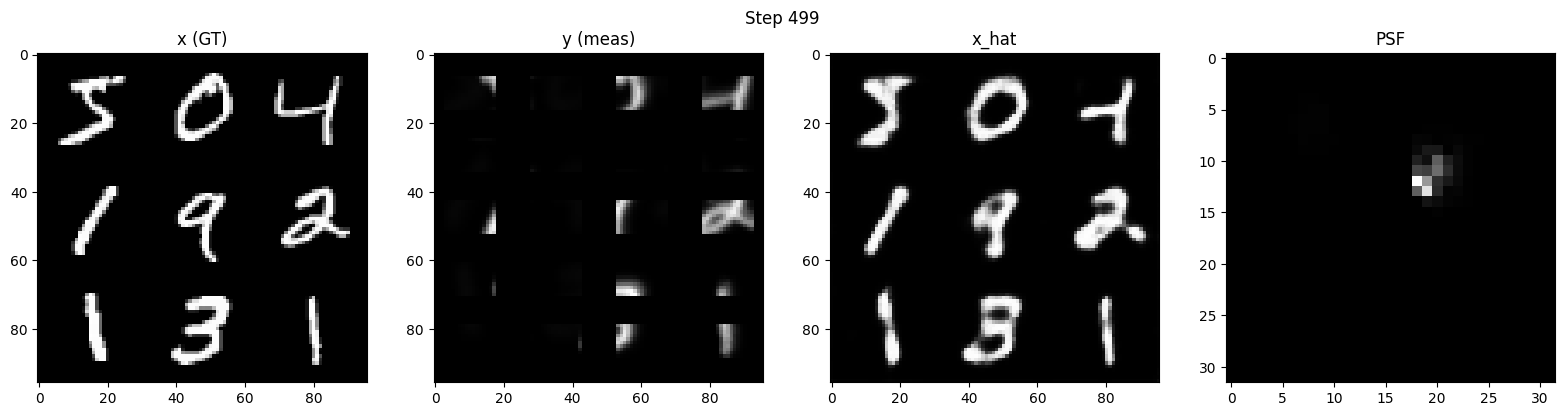

100%|██████████| 500/500 [21:05<00:00,  2.53s/it]


In [10]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=num_steps,
    log_every=log_every,
    visualize_every=visualize_every,
    key=subkey_3
)